In [28]:
from z01_data_preprocessing import(
    load_and_prepare_data, slice_by_dates, handle_duplicate_values, reindex_daily, handle_outliers, filter_by_reflectance,
    calculate_stats_from_random_points, filter_columns, handle_missing_values, smooth_data, obs_data)

from z02_daily_time_series_generation import generate_daily_landsat_series, plot_residuals_boxplot, plot_landsat_bands

from z03_features_processing import(
    process_spectral_data, principal_component_analysis, cross_correlations_analysis, merge_datasets,
    add_lags, add_time)

from z04_modelling_framework import(
    preprocess_for_ML_chrono, tune_model, train_model, evaluate_model, plot_pred_vs_real, apply_model, 
    plot_timeseries_results
)

# -----------------------------
# 1. Study site selection
# -----------------------------

study_site = 'SDH1'
start_date = '2015'
end_date = '2026'

if study_site == 'SDH1':
    target = 'SDH1PS01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH1_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH1_MT_500m_2000-03_2026-06.csv'
    landsat_filepath = '../data/processed/satellites/SDH1_L_30m_1984-07_2026-06.csv'
    sentinel_filepath = '../data/processed/satellites/SDH1_S2_20m_2015-10_2026-06.csv'

elif study_site == 'SDH2':
    target = 'SDH2PP01_gw-depth_m'
    insitu_filepath = '../data/processed/in-situ/SDH2_daily-insitu-data.csv'
    modis_filepath = '../data/processed/satellites/SDH2_MT_500m_2000-03_2026-06.csv'

else:
    print(f'{study_site} not supported as study site')


# -----------------------------
# 2. Remote data preprocessing
# -----------------------------

modis_df = (
    load_and_prepare_data(filepath=modis_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
    .pipe(filter_columns, cols_to_keep=['blue', 'green', 'red', 'nir', 'swir1', 'swir2'])
    .pipe(slice_by_dates, startDate=start_date, endDate=end_date)
    .pipe(filter_by_reflectance)
    .pipe(handle_duplicate_values)
    .pipe(reindex_daily)
    .pipe(handle_outliers, z_thresh=3.0)
    .pipe(handle_missing_values, method='time')
    .pipe(smooth_data, window_length=17, polyorder=2)
)

landsat_df = (
    load_and_prepare_data(filepath=landsat_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
    .pipe(slice_by_dates, startDate=start_date, endDate=end_date)
    .pipe(filter_by_reflectance)
    .pipe(handle_duplicate_values)
    .pipe(reindex_daily)
    .pipe(handle_outliers, z_thresh=3.0)
    .pipe(calculate_stats_from_random_points, minPoints=10)
    .pipe(filter_columns, cols_to_keep=['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean'])
)

sentinel_df = (
    load_and_prepare_data(filepath=sentinel_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
    .pipe(slice_by_dates, startDate=start_date, endDate=end_date)
    .pipe(filter_by_reflectance)
    .pipe(handle_duplicate_values)
    .pipe(reindex_daily)
    .pipe(handle_outliers, z_thresh=3.0)
    .pipe(calculate_stats_from_random_points, minPoints=10)
    .pipe(filter_columns, cols_to_keep=['blue_mean', 'green_mean', 'red_mean', 'nir_mean', 'swir1_mean', 'swir2_mean'])
)

# insitu_df = (
#     load_and_prepare_data(filepath=insitu_filepath, index_col='Timestamps', date_format='%Y-%m-%d', sep=',')
#     .pipe(handle_duplicate_values)
#     .pipe(reindex_daily)
#     .pipe(handle_outliers, z_thresh=3.0)
#     .pipe(filter_columns, cols_to_keep=[target])
#     .pipe(handle_missing_values, method='drop')
# )

sentinel_df_interpolated = (
    handle_missing_values(sentinel_df, method='time')
    .pipe(smooth_data, window_length=7, polyorder=2)
)


Processing blue (335 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.737
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     649.1
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           3.64e-69
Time:                        18:03:01   Log-Likelihood:                 417.53
No. Observations:                 234   AIC:                            -831.1
Df Residuals:                     232   BIC:                            -824.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

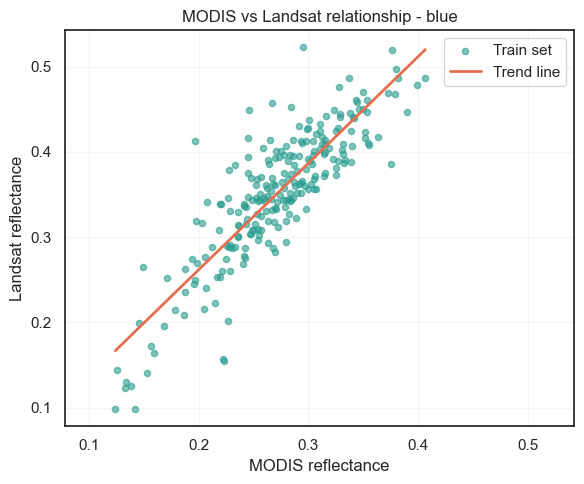

--- blue: Model evaluation ---
Train - R2: 0.74 | MAE: 0.0308 | RMSE: 0.0406
Test  - R2: 0.75 | MAE: 0.0286 | RMSE: 0.0396


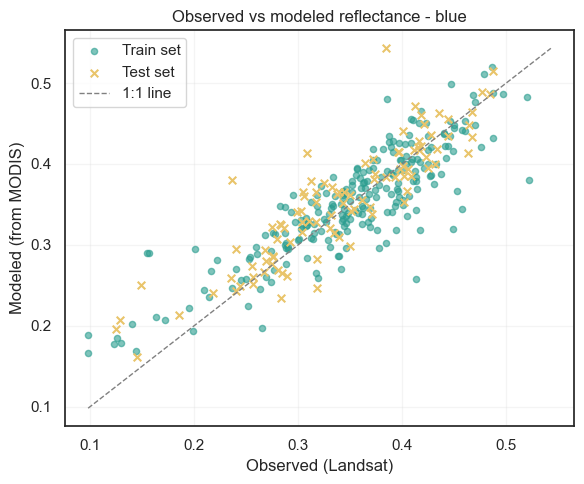


Processing green (335 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.725
Method:                 Least Squares   F-statistic:                     616.7
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           2.82e-67
Time:                        18:03:01   Log-Likelihood:                 401.93
No. Observations:                 234   AIC:                            -799.9
Df Residuals:                     232   BIC:                            -793.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

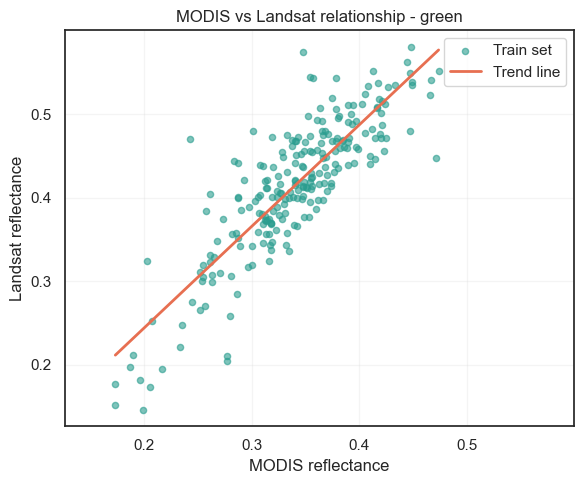

--- green: Model evaluation ---
Train - R2: 0.73 | MAE: 0.0327 | RMSE: 0.0434
Test  - R2: 0.75 | MAE: 0.0306 | RMSE: 0.0419


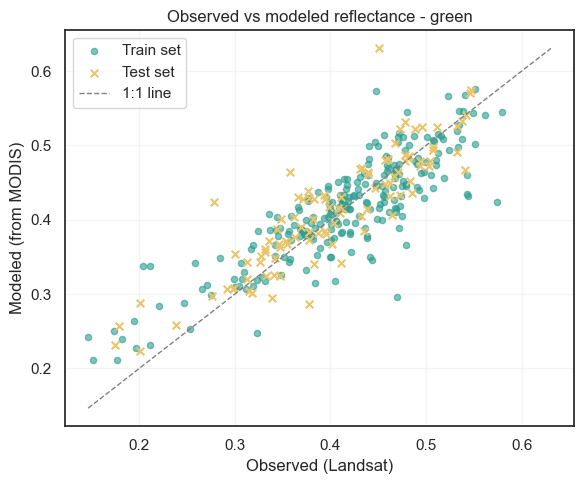


Processing red (327 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     548.3
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           2.32e-62
Time:                        18:03:01   Log-Likelihood:                 380.72
No. Observations:                 228   AIC:                            -757.4
Df Residuals:                     226   BIC:                            -750.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

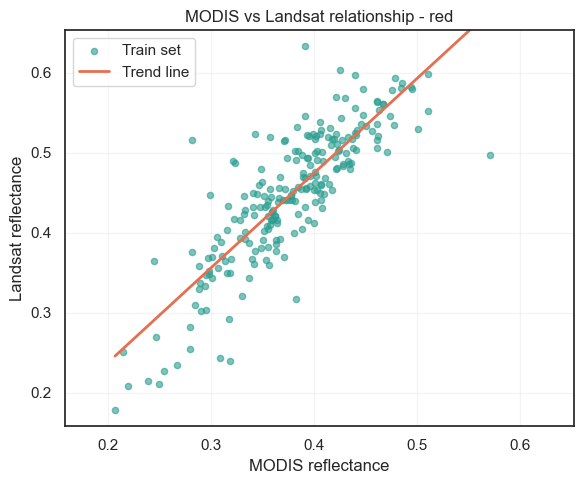

--- red: Model evaluation ---
Train - R2: 0.71 | MAE: 0.0327 | RMSE: 0.0456
Test  - R2: 0.78 | MAE: 0.0346 | RMSE: 0.0426


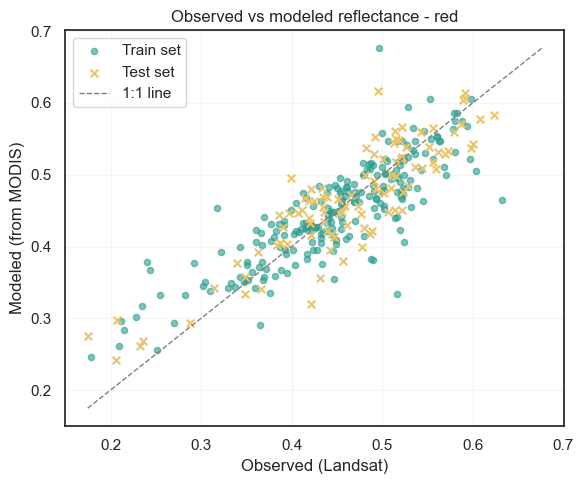


Processing nir (336 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     527.1
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           9.39e-62
Time:                        18:03:01   Log-Likelihood:                 394.92
No. Observations:                 235   AIC:                            -785.8
Df Residuals:                     233   BIC:                            -778.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       

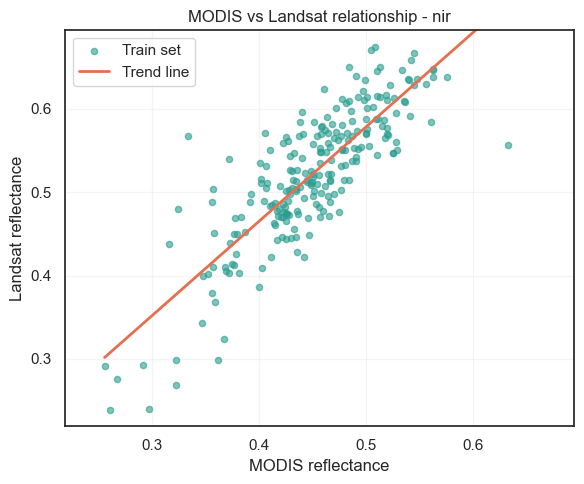

--- nir: Model evaluation ---
Train - R2: 0.69 | MAE: 0.0344 | RMSE: 0.0451
Test  - R2: 0.68 | MAE: 0.0394 | RMSE: 0.0518


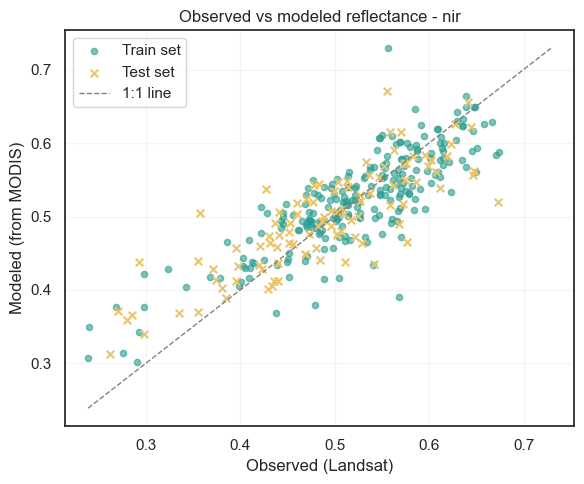


Processing swir1 (336 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.763
Method:                 Least Squares   F-statistic:                     753.5
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           5.76e-75
Time:                        18:03:01   Log-Likelihood:                 406.00
No. Observations:                 235   AIC:                            -808.0
Df Residuals:                     233   BIC:                            -801.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

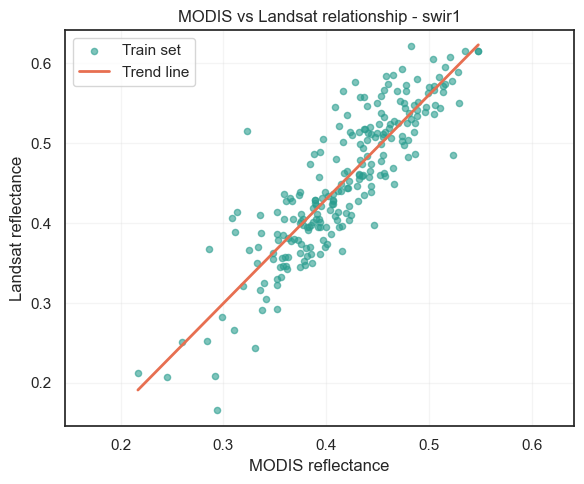

--- swir1: Model evaluation ---
Train - R2: 0.76 | MAE: 0.0327 | RMSE: 0.0430
Test  - R2: 0.73 | MAE: 0.0379 | RMSE: 0.0504


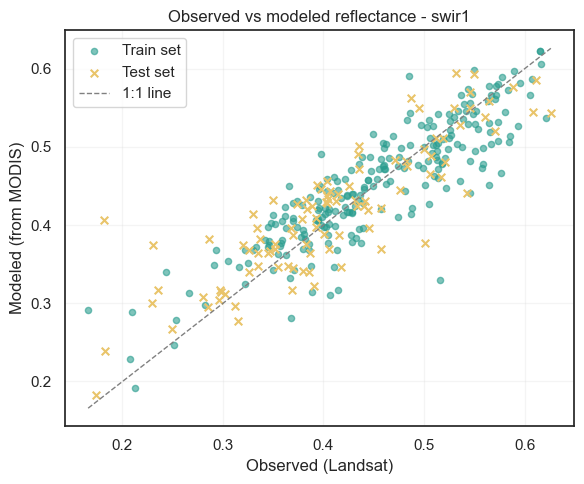


Processing swir2 (336 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.797
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     912.1
Date:                Thu, 13 Aug 2026   Prob (F-statistic):           1.61e-82
Time:                        18:03:01   Log-Likelihood:                 418.20
No. Observations:                 235   AIC:                            -832.4
Df Residuals:                     233   BIC:                            -825.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

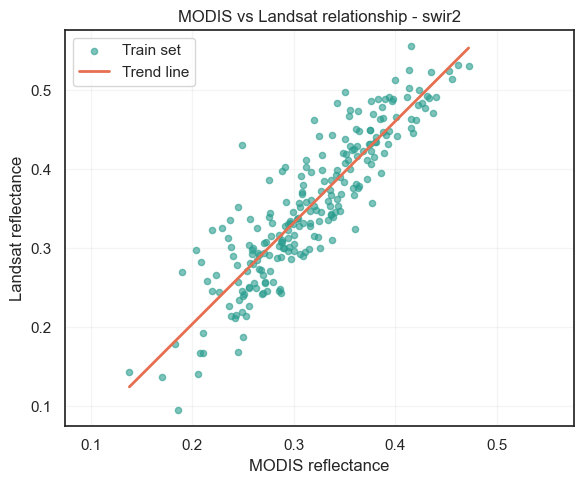

--- swir2: Model evaluation ---
Train - R2: 0.80 | MAE: 0.0318 | RMSE: 0.0408
Test  - R2: 0.78 | MAE: 0.0378 | RMSE: 0.0472


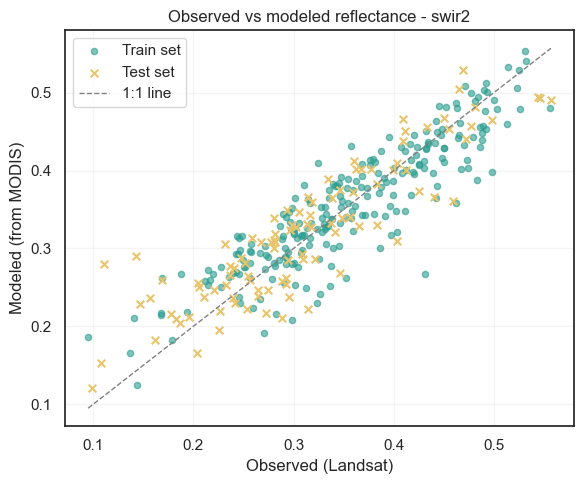


Processing blue (1029 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     1497.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          8.13e-178
Time:                        18:03:01   Log-Likelihood:                 976.84
No. Observations:                 720   AIC:                            -1950.
Df Residuals:                     718   BIC:                            -1941.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     

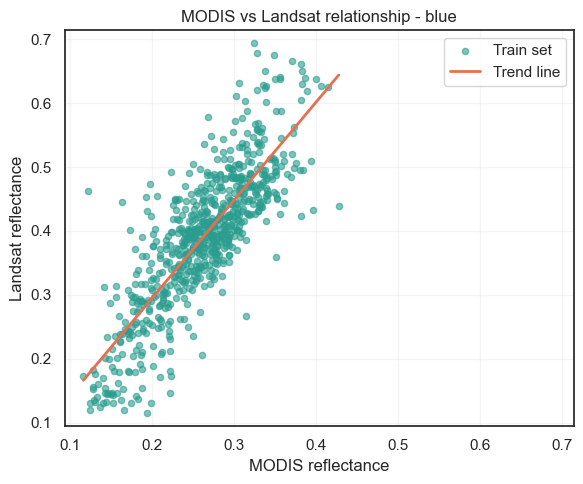

--- blue: Model evaluation ---
Train - R2: 0.68 | MAE: 0.0478 | RMSE: 0.0623
Test  - R2: 0.70 | MAE: 0.0458 | RMSE: 0.0607


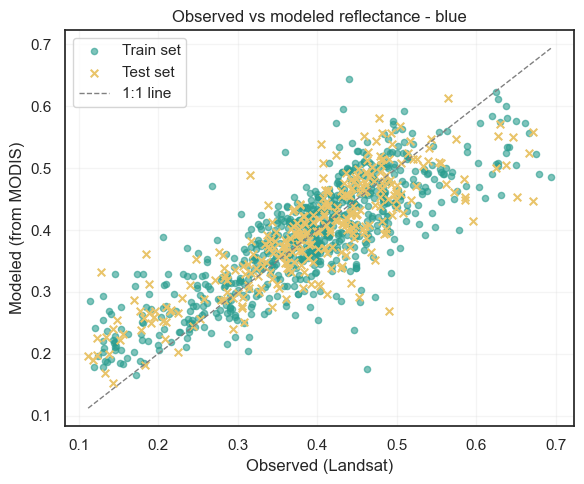


Processing green (1029 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.642
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     1286.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          3.57e-162
Time:                        18:03:01   Log-Likelihood:                 943.42
No. Observations:                 720   AIC:                            -1883.
Df Residuals:                     718   BIC:                            -1874.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

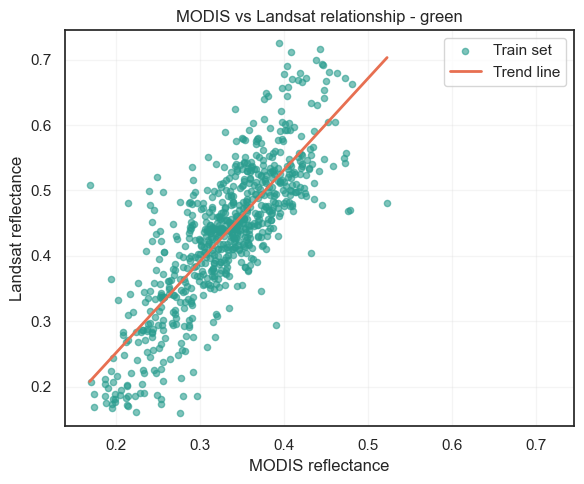

--- green: Model evaluation ---
Train - R2: 0.64 | MAE: 0.0501 | RMSE: 0.0653
Test  - R2: 0.66 | MAE: 0.0472 | RMSE: 0.0635


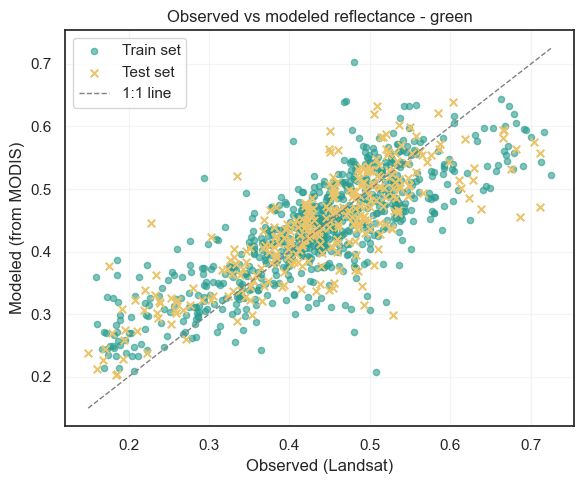


Processing red (1029 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     1314.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          2.56e-164
Time:                        18:03:02   Log-Likelihood:                 946.23
No. Observations:                 720   AIC:                            -1888.
Df Residuals:                     718   BIC:                            -1879.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

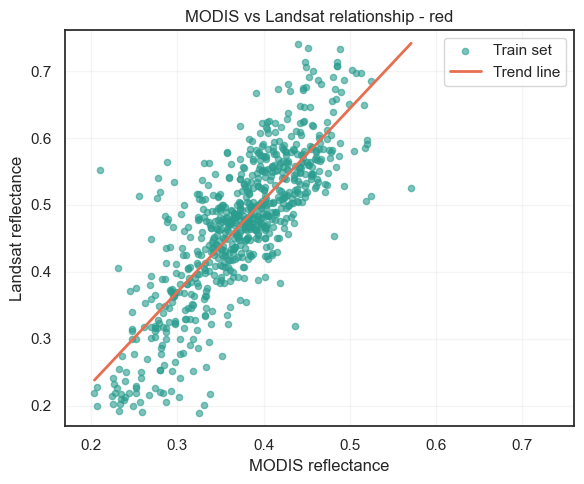

--- red: Model evaluation ---
Train - R2: 0.65 | MAE: 0.0495 | RMSE: 0.0650
Test  - R2: 0.66 | MAE: 0.0464 | RMSE: 0.0633


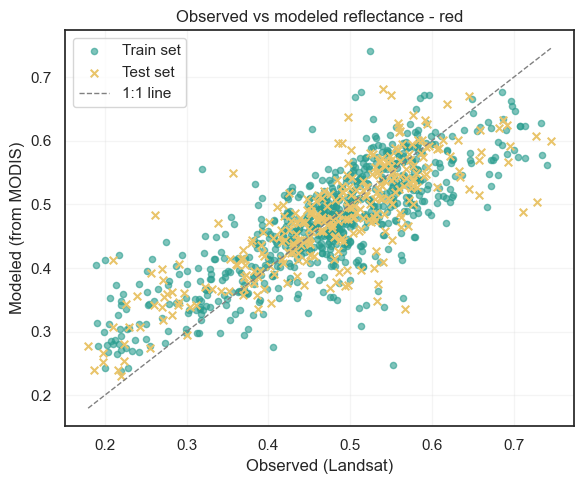


Processing nir (1029 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1072.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          1.36e-144
Time:                        18:03:02   Log-Likelihood:                 918.98
No. Observations:                 720   AIC:                            -1834.
Df Residuals:                     718   BIC:                            -1825.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      

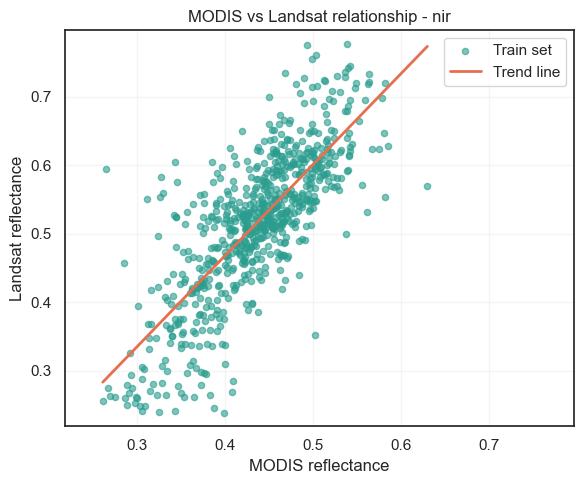

--- nir: Model evaluation ---
Train - R2: 0.60 | MAE: 0.0511 | RMSE: 0.0675
Test  - R2: 0.62 | MAE: 0.0476 | RMSE: 0.0658


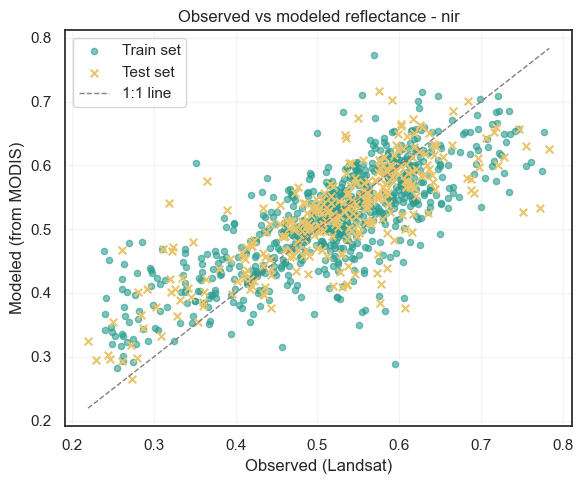


Processing swir1 (1028 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.658
Method:                 Least Squares   F-statistic:                     1380.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          3.14e-169
Time:                        18:03:02   Log-Likelihood:                 1031.2
No. Observations:                 719   AIC:                            -2058.
Df Residuals:                     717   BIC:                            -2049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

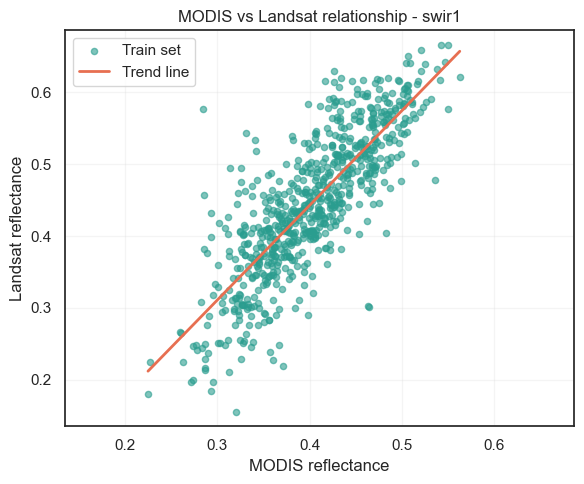

--- swir1: Model evaluation ---
Train - R2: 0.66 | MAE: 0.0439 | RMSE: 0.0577
Test  - R2: 0.67 | MAE: 0.0443 | RMSE: 0.0581


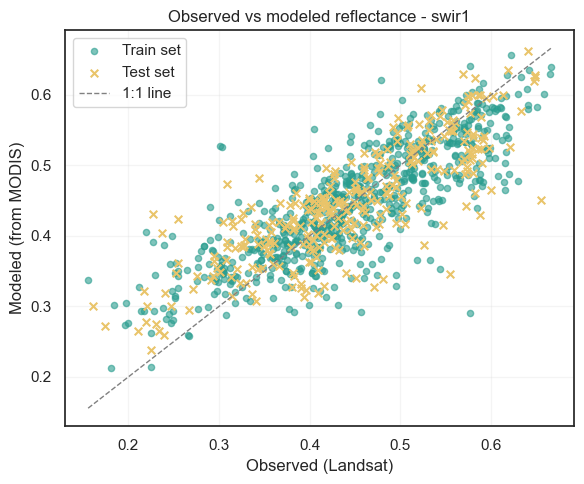


Processing swir2 (1029 coincident points)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     1614.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):          8.16e-186
Time:                        18:03:02   Log-Likelihood:                 1059.2
No. Observations:                 720   AIC:                            -2114.
Df Residuals:                     718   BIC:                            -2105.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const    

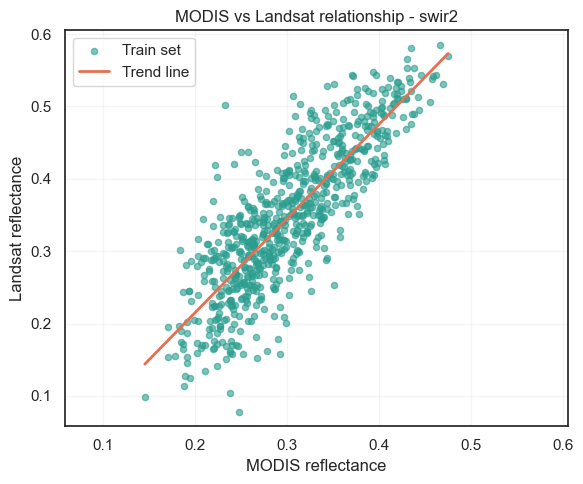

--- swir2: Model evaluation ---
Train - R2: 0.69 | MAE: 0.0435 | RMSE: 0.0556
Test  - R2: 0.71 | MAE: 0.0417 | RMSE: 0.0534


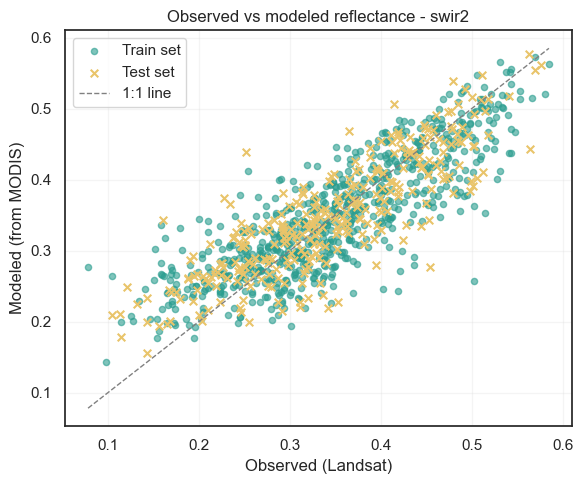

In [29]:
# -----------------------------
# 3. Daily satellite series
# -----------------------------

band_mapping = {
    'blue':  ('blue_mean',  'blue'),
    'green': ('green_mean', 'green'),
    'red':   ('red_mean',   'red'),
    'nir':   ('nir_mean',   'nir'),
    'swir1': ('swir1_mean', 'swir1'),
    'swir2': ('swir2_mean', 'swir2')
}

landsat_daily_df, landsat_residuals_df = generate_daily_landsat_series(landsat_df, modis_df, band_mapping)
# plot_residuals_boxplot(landsat_residuals_df)
# plot_landsat_bands(landsat_daily_df, landsat_df, landsat_residuals_df, start_date, end_date)

sentinel_daily_df, sentinel_residuals_df = generate_daily_landsat_series(sentinel_df, modis_df, band_mapping)
# plot_residuals_boxplot(sentinel_residuals_df)
# plot_landsat_bands(sentinel_daily_df, sentinel_df, sentinel_residuals_df, start_date, end_date)

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

def compare_landsat_series(daily_df, daily_df2, original_df, start, end):
    """
    Filtra los DataFrames por fechas y genera un gráfico apilado comparando 
    dos series modeladas (daily_df y daily_df2) y los valores originales para cada banda.
    """
    sns.set_theme(style="white")
    
    # 1. Filtrar los DataFrames
    df_daily1 = slice_by_dates(daily_df, start, end)
    df_daily2 = slice_by_dates(daily_df2, start, end)
    df_orig = slice_by_dates(original_df, start, end)

    bands = ['blue', 'green', 'red', 'nir', 'swir1', 'swir2']
    colors1 = ['blue', 'green', 'red', 'purple', 'orange', 'saddlebrown']
    colors2 = ['navy', 'darkgreen', 'darkred', 'indigo', 'darkorange', 'maroon']
    
    fig, axes = plt.subplots(len(bands), 1, figsize=(40, 28), sharex=True, sharey=True)
    
    for i, (ax, band, c1, c2) in enumerate(zip(axes, bands, colors1, colors2)):
        
        label_daily1 = 'Serie sintética' if i == 0 else None
        label_daily2 = 'Serie interpolada' if i == 0 else None
        label_original = 'Original' if i == 0 else None

        # --- VALIDACIÓN DE COLUMNAS PARA DAILY_DF2 ---
        if band in df_daily2.columns:
            col_daily2 = band
        elif f'{band}_mean' in df_daily2.columns:
            col_daily2 = f'{band}_mean'
        else:
            print(f"Advertencia: No se encontró la columna '{band}' ni '{band}_mean' en daily_df2.")
            col_daily2 = None

        # Gráfico de líneas (Serie 1)
        if band in df_daily1.columns:
            sns.lineplot(
                x=df_daily1.index, y=df_daily1[band], 
                color=c1, label=label_daily1, ax=ax, linewidth=1.5
            )
        
        # Gráfico de líneas (Serie 2)
        if col_daily2 is not None:
            sns.lineplot(
                x=df_daily2.index, y=df_daily2[col_daily2], 
                color=c2, label=label_daily2, ax=ax, linewidth=1.5, linestyle='--'
            )
        
        # # Gráfico de dispersión (Original)
        # col_orig = f'{band}_mean' if f'{band}_mean' in df_orig.columns else band
        # if col_orig in df_orig.columns:
        #     sns.scatterplot(
        #         x=df_orig.index, y=df_orig[col_orig], 
        #         color='black', s=8, label=label_original, ax=ax, edgecolor=None, zorder=3
        #     )
        
        ax.set_ylabel('Reflectance' if i == 0 else '')
        ax.set_title(f'Band: {band.upper()}', loc='right', fontsize=10, color='dimgray')
        
        if i == 0:
            ax.legend(loc='upper left', frameon=True)
        else:
            if ax.get_legend() is not None:
                ax.get_legend().remove()
            
    plt.tight_layout()
    plt.show()


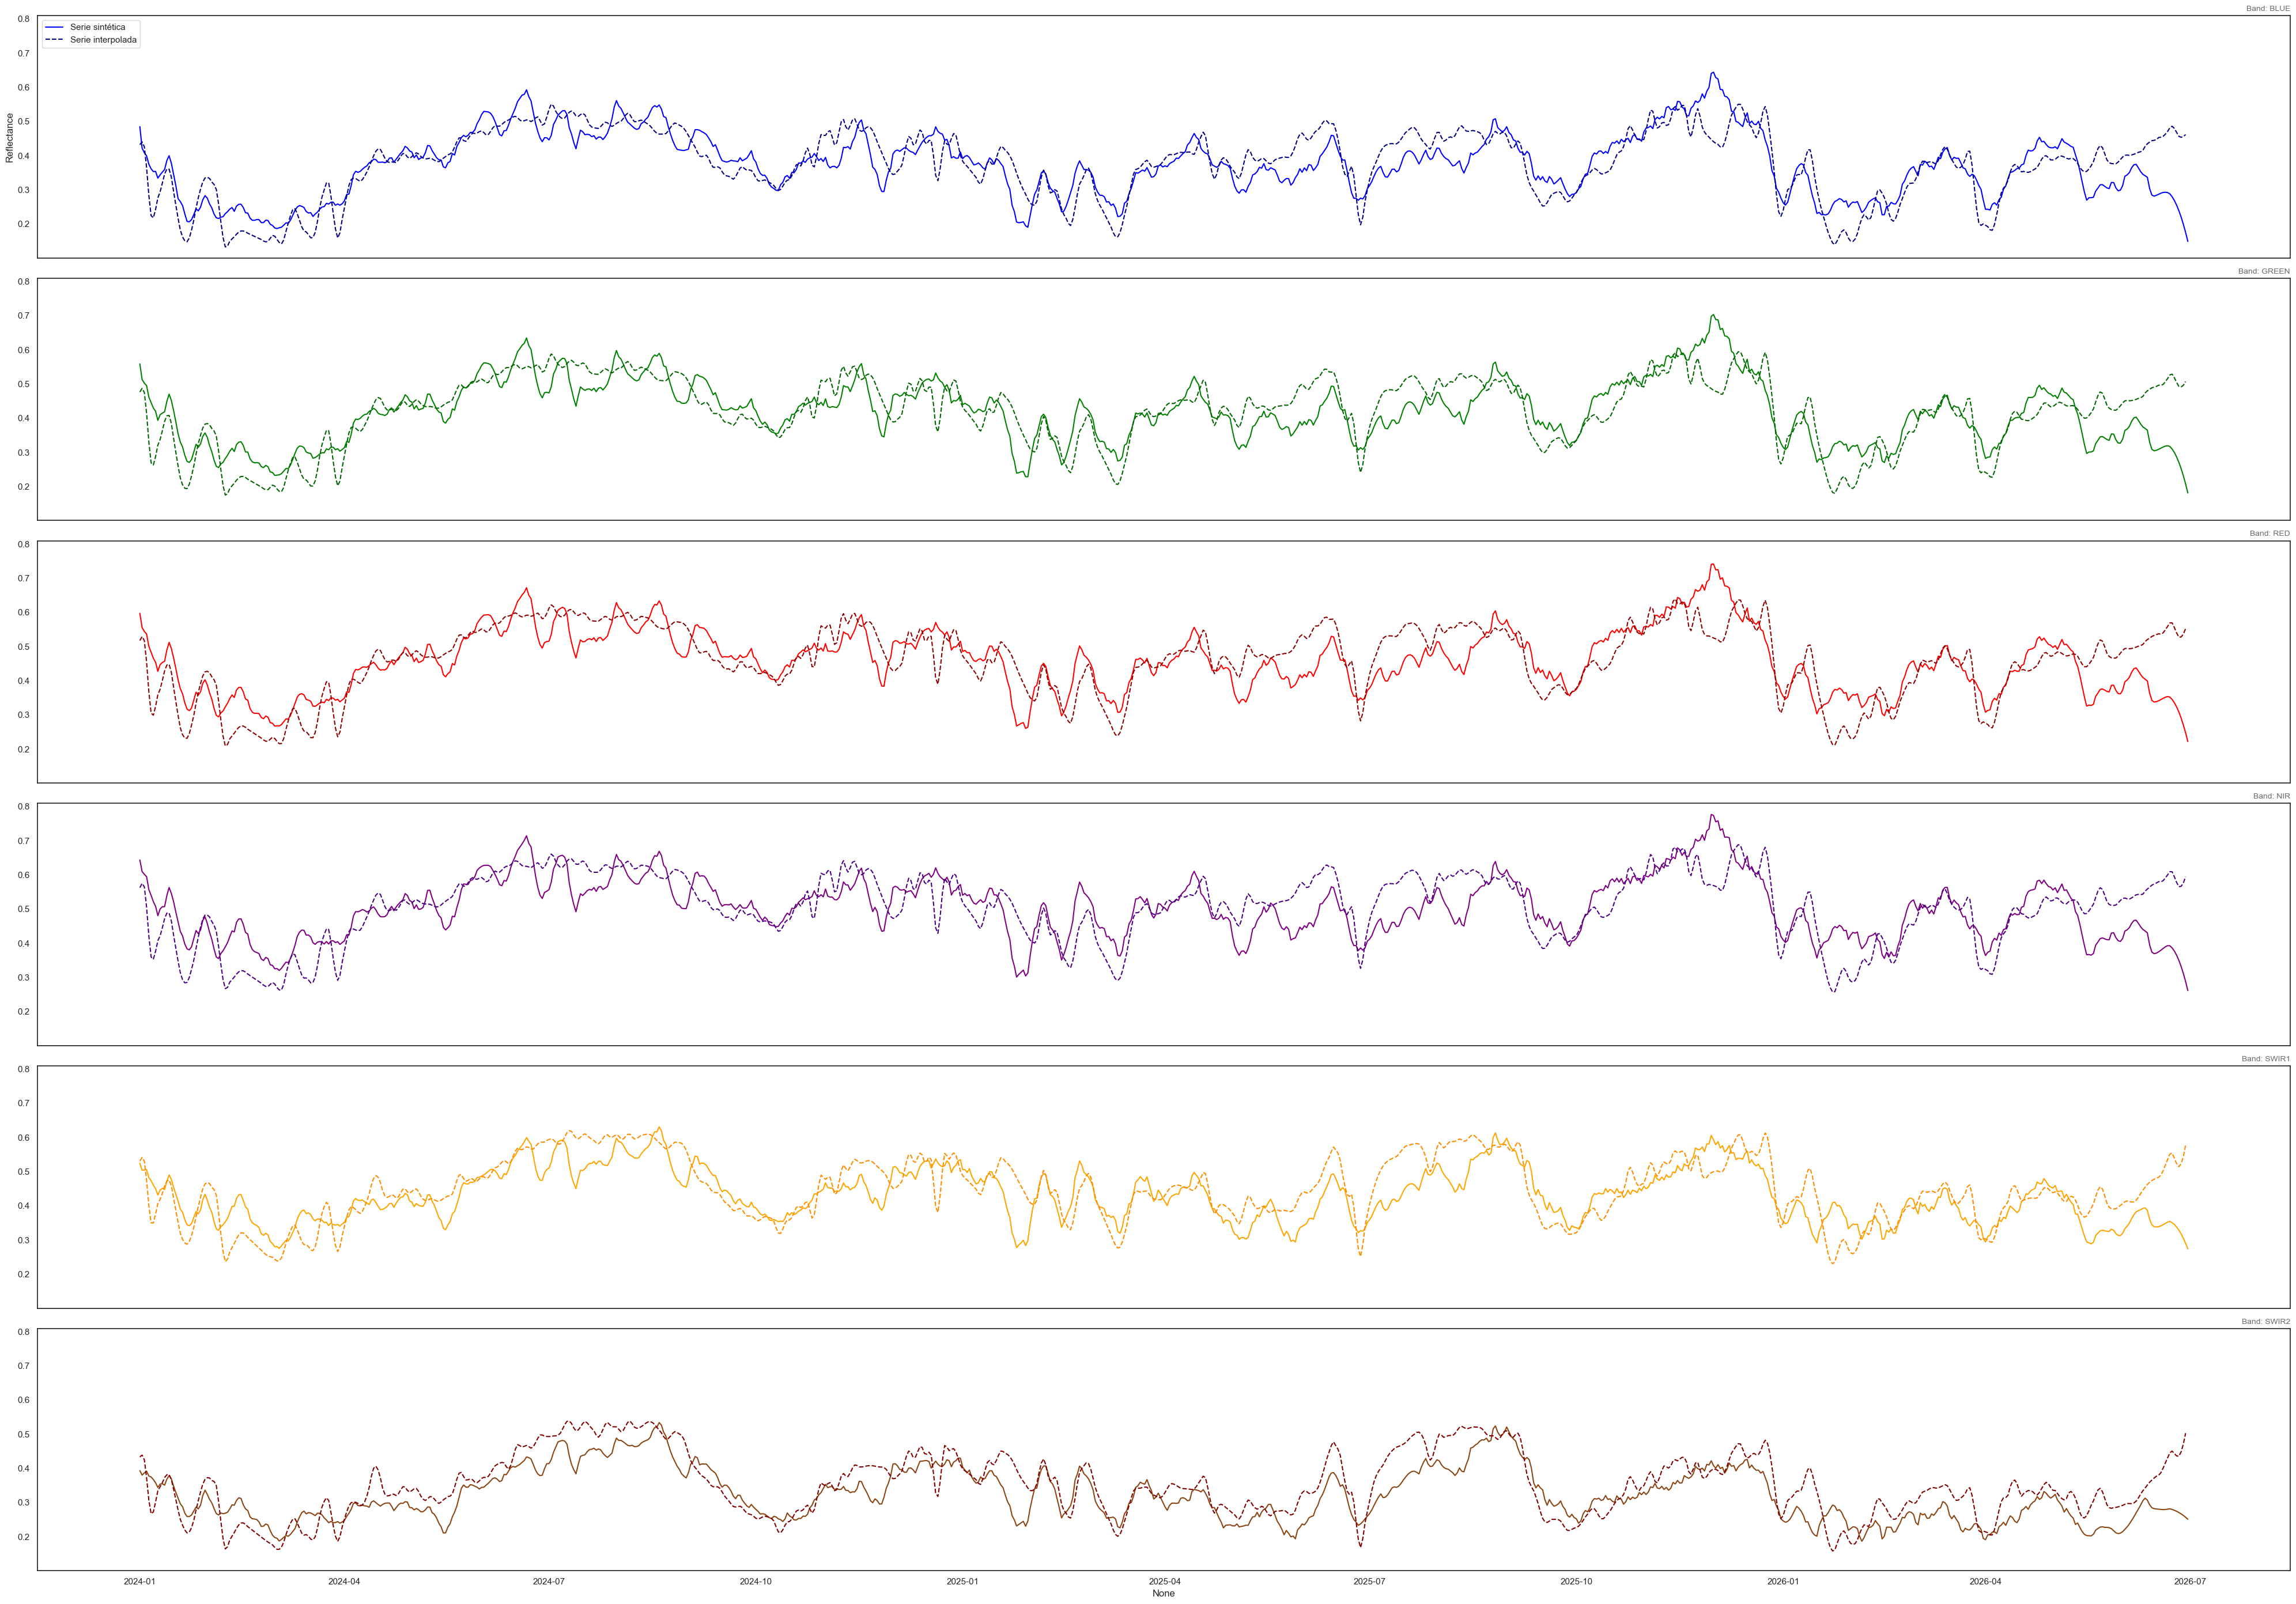

In [35]:
# sentinel sintetica vs sentinel interpolada
compare_landsat_series(sentinel_daily_df, sentinel_df_interpolated, sentinel_df, '2024', '2026')

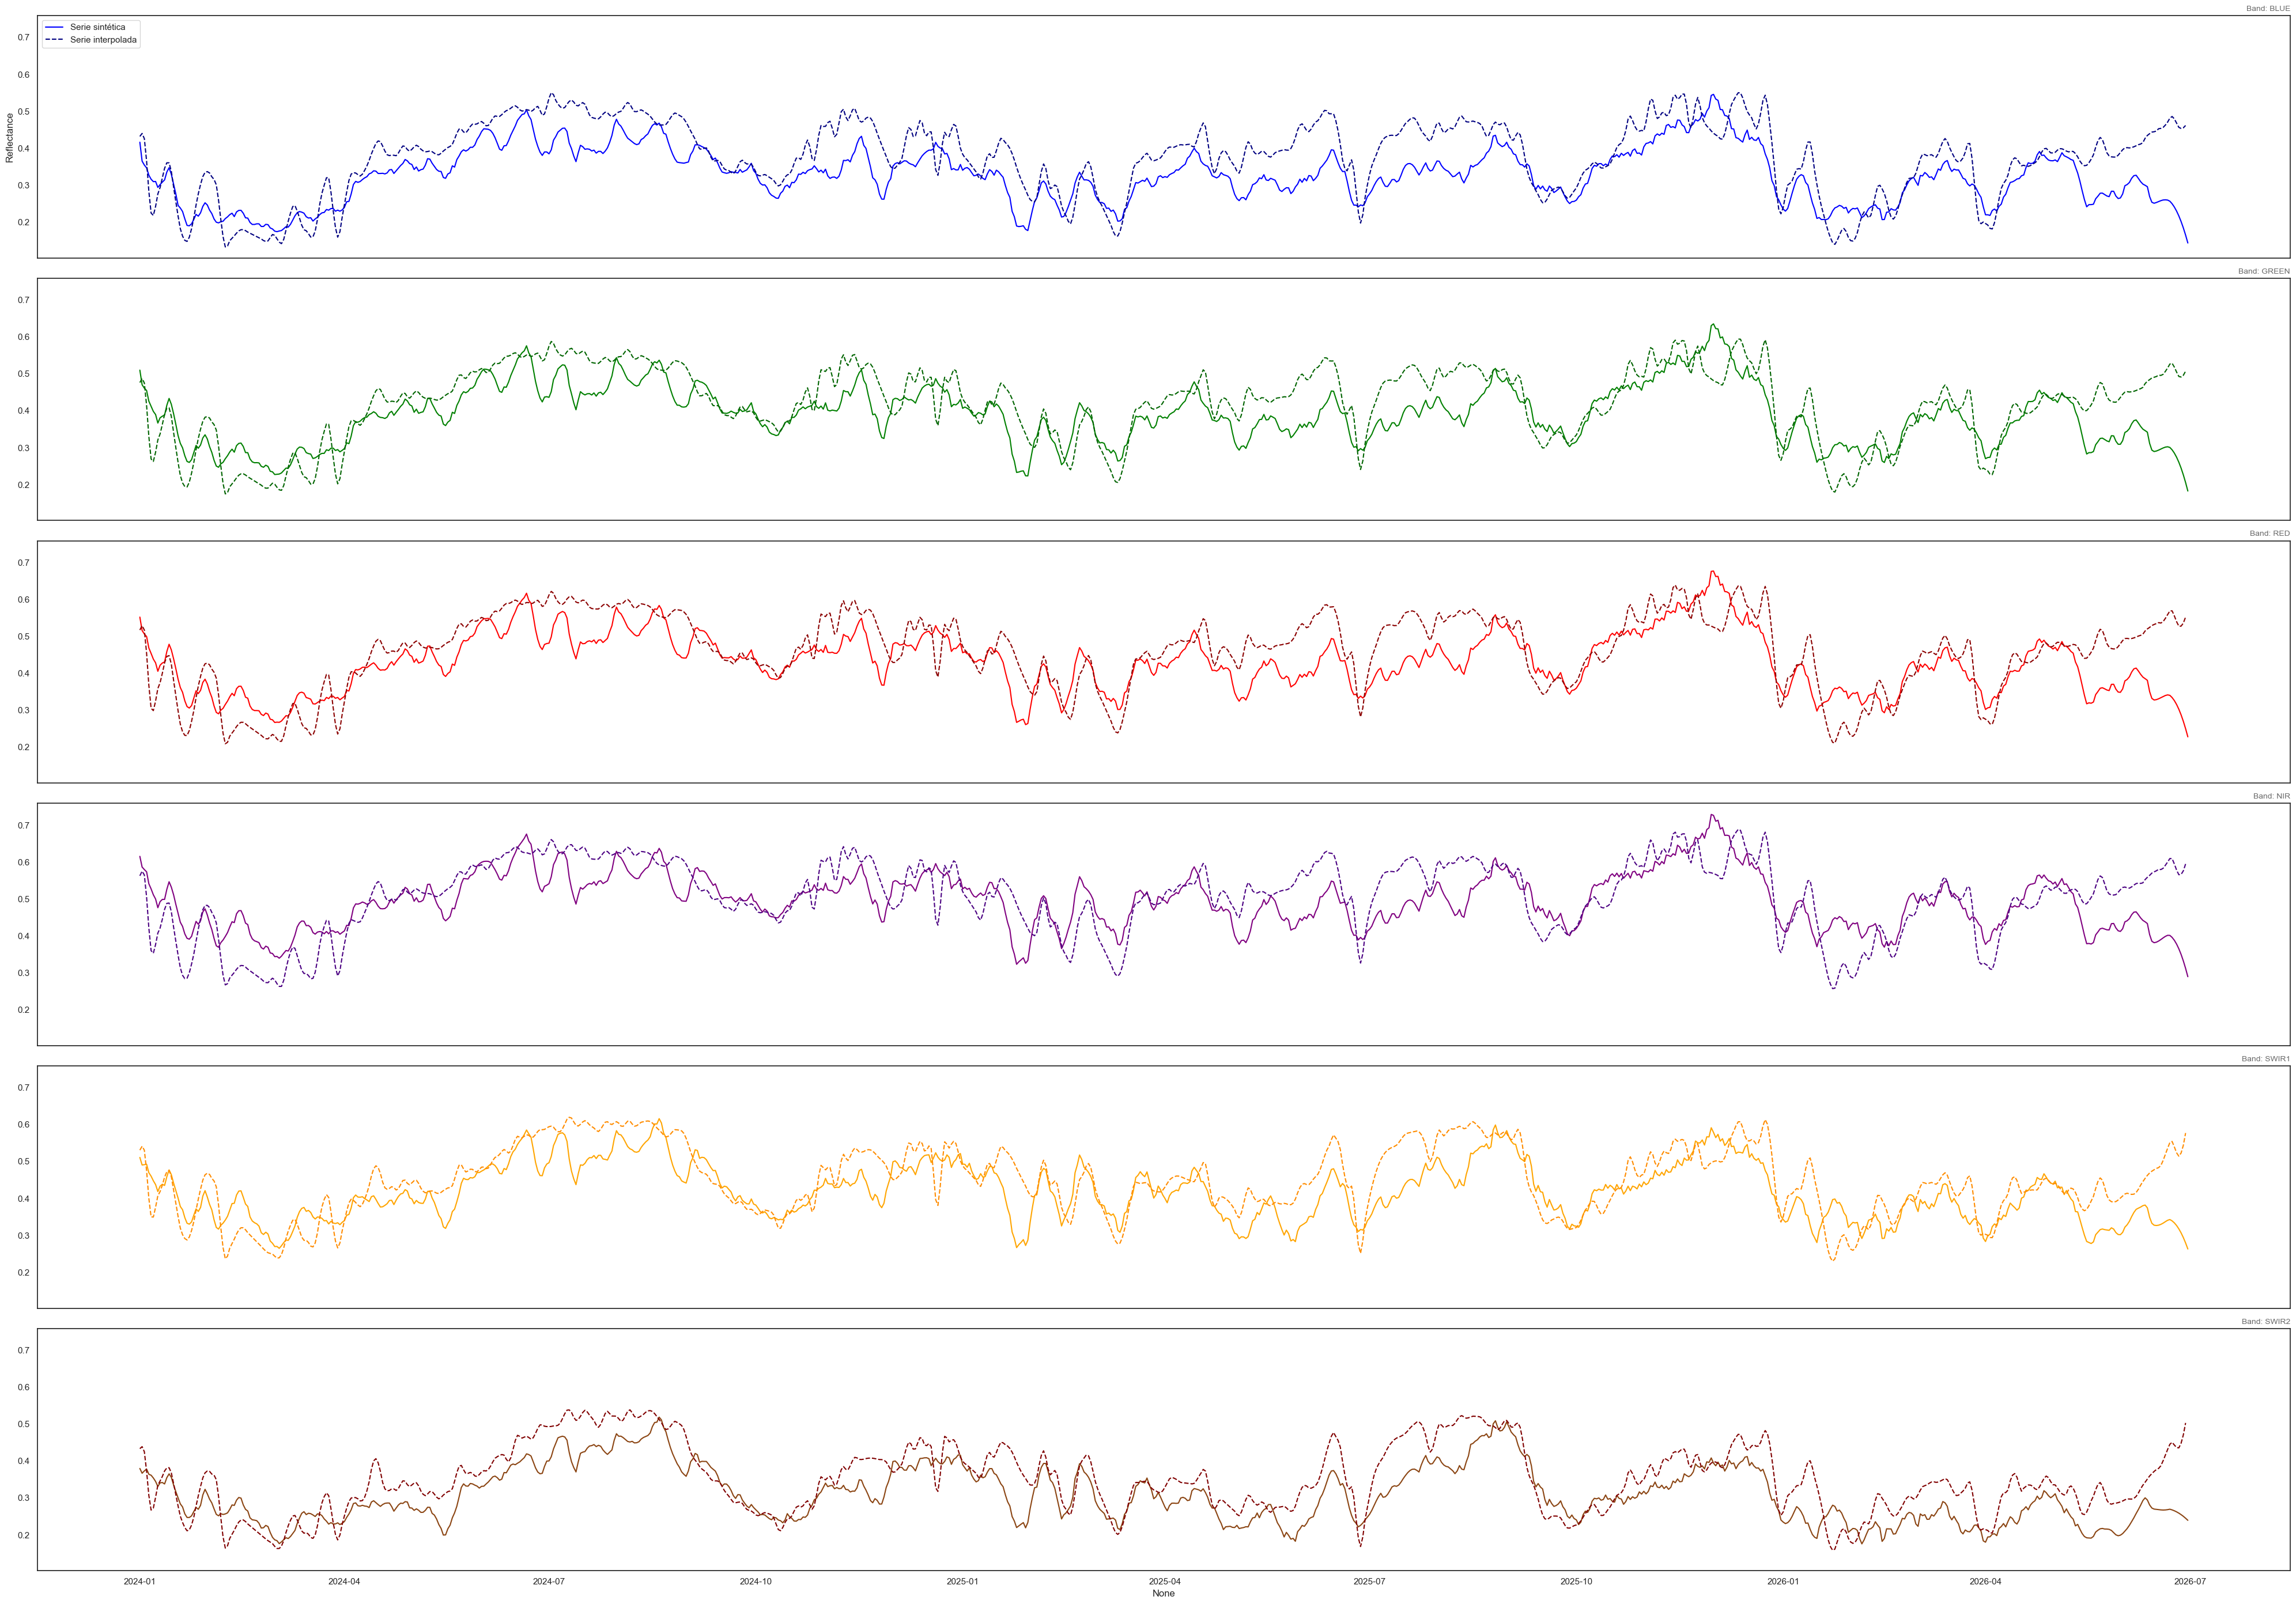

In [36]:
# landsat sintetica vs sentinel interpolada
compare_landsat_series(landsat_daily_df, sentinel_df_interpolated, sentinel_df, '2024', '2026')